[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/colab-version/L03/L03_monotonicity_MP1_MP2_concepts.ipynb)


# Illustrating MP1 and MP2 (Monotonicity Analysis) on an Engineering Design Problem

This notebook illustrates the **First** and **Second Monotonicity
Principles** (MP1, MP2), and the related concepts of **activity**,
**criticality**, **dominance**, **consistency**, and **relaxation**,
from monotonicity-based model-boundedness analysis (Papalambros &
Wilde, *Principles of Optimal Design*, Ch. 3), using:

1. two tiny "warm-up" toy problems to build intuition for MP1/MP2, then
2. a small but genuine engineering design problem — sizing a **hydraulic
   cylinder actuator** — worked out by hand with MP1/MP2 and a
   **monotonicity table**, then examined through the lens of activity,
   criticality, dominance, and consistency, and finally
   **checked two independent ways**: analytically and with a numerical
   constrained optimizer.

**Recap of the two principles**

> **MP1 (First Monotonicity Principle).** In a well-constrained
> minimization problem, every variable that appears *increasingly* in the
> objective must be bounded below by at least one *nonincreasing* active
> constraint (and symmetrically, a *decreasing* objective variable must be
> bounded above by a *nondecreasing* active constraint). If only **one**
> constraint can supply that bound, it is called **critical** and must be
> active.

> **MP2 (Second Monotonicity Principle).** Any variable that does **not**
> appear in the objective at all (a *nonobjective* variable) must still be
> bounded **both above and below** — by a nonincreasing constraint from
> below and a nondecreasing constraint from above — otherwise it could run
> away to $0$ or $\infty$ without the objective "noticing." These bounds
> are typically only **semiactive**, not necessarily active.



## Part 1 — Warm-up: MP1 in one variable

Take the trivial problem $\min f(x) = x$ over the positive domain
$\mathcal P = \{x : 0 < x < \infty\}$.

* With **no constraint**, $f$ decreases toward $0$ as $x\to 0^+$: the
  infimum is approached only at $x=0\notin\mathcal P$, so the problem is
  **not well bounded** (left panel below).
* Add a single inequality $g:\; -x + a \le 0$ (i.e. $x \ge a$). Since $g$
  is the *only* constraint touching $x$ and it is exactly the
  nonincreasing kind MP1 asks for, it is **critical** — it must be active,
  giving $x^{*} = a$ (right panel).


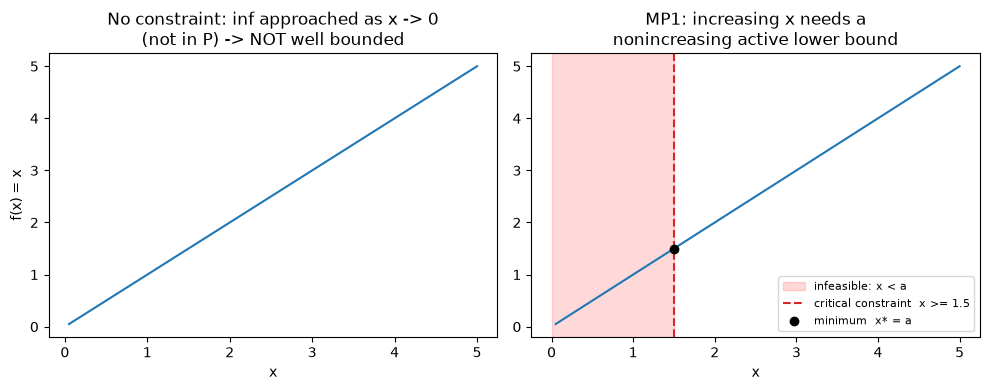

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.05, 5, 200)
a = 1.5

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x, x, color="tab:blue")
axes[0].set_title("No constraint: inf approached as x -> 0\n(not in P) -> NOT well bounded")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x) = x")

axes[1].plot(x, x, color="tab:blue")
axes[1].axvspan(0, a, color="red", alpha=0.15, label="infeasible: x < a")
axes[1].axvline(a, color="tab:red", ls="--", label=f"critical constraint  x >= {a}")
axes[1].scatter([a], [a], color="black", zorder=5, label="minimum  x* = a")
axes[1].set_title("MP1: increasing x needs a\nnonincreasing active lower bound")
axes[1].set_xlabel("x"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()



## Part 2 — Warm-up: MP2, a variable that isn't in the objective

Now suppose $f(x,y) = x$ (it simply does not depend on $y$ at all), with
$y$ appearing only in two inequalities: $g_{lo}: y \ge 1$ and
$g_{hi}: y \le 5$.

The objective is completely flat in $y$ — no value of $y$ in its
feasible range changes $f$. Yet **both** bounds are still needed:
without $g_{lo}$, $y$ could drift to $0\notin\mathcal P$; without
$g_{hi}$, $y$ could drift to $\infty$. That is exactly MP2: a
nonobjective variable must be pinned down on **both** sides, even though
neither bound is forced to be active by the objective itself (they are
*semiactive* at best).


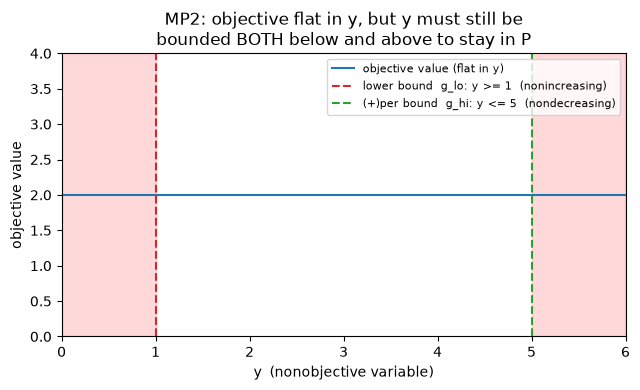

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 4))
y = np.linspace(0, 6, 200)
f_flat = np.full_like(y, 2.0)          # objective value, independent of y

ax.plot(y, f_flat, color="tab:blue", label="objective value (flat in y)")
ax.axvspan(0, 1, color="red", alpha=0.15)
ax.axvspan(5, 6, color="red", alpha=0.15)
ax.axvline(1, color="tab:red", ls="--", label="lower bound  g_lo: y >= 1  (nonincreasing)")
ax.axvline(5, color="tab:green", ls="--", label="(+)per bound  g_hi: y <= 5  (nondecreasing)")
ax.set_xlim(0, 6); ax.set_ylim(0, 4)
ax.set_xlabel("y  (nonobjective variable)"); ax.set_ylabel("objective value")
ax.set_title("MP2: objective flat in y, but y must still be\nbounded BOTH below and above to stay in P")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()



## Part 3 — Case study: hydraulic cylinder actuator

Now a real (if simplified) design problem, structured exactly like the
classic hydraulic-cylinder example in Ch. 3 of the text: two variables
appear in the objective (MP1 applies to them directly), and three more
variables are linked through the constraints only, not the objective
(MP2 applies to them).

**Design variables** (SI units throughout, so every check below is
dimensionally consistent):

| symbol | meaning |
|---|---|
| $i$ | inside (bore) diameter of the cylinder [m] |
| $t$ | wall thickness [m] |
| $F$ | actuation force delivered [N] |
| $p$ | hydraulic supply pressure [Pa] |
| $s$ | hoop (wall) stress in the cylinder [Pa] |

**Objective** — minimize the outside diameter (a proxy for material use
and cost):
$$\min\; D = i + 2t$$

**Physical relations (equalities)**
$$h_1:\; F = \tfrac{\pi}{4} i^2 p \qquad\text{(force = pressure} \times \text{piston area)}$$
$$h_2:\; s = \dfrac{i\,p}{2t} \qquad\text{(thin-wall hoop stress)}$$

**Design requirements (inequalities)**
$$g_1:\; t \ge t_{\min}\qquad g_2:\; F \ge F_{\min}\qquad
  g_3:\; p \le p_{\max}\qquad g_4:\; s \le s_{\text{allow}}$$

Only $i$ and $t$ appear in the objective — they are the **objective
variables** governed by MP1. The variables $F,p,s$ appear **only** in
the constraints — they are **nonobjective variables** governed by MP2.

(Note: the force is capitalized as $F$ throughout this example
specifically to avoid confusion with $f$, the generic symbol used for
the *objective function* itself in Parts 1–2 and in the statements of
MP1/MP2.)


In [22]:
import numpy as np

# ---- design parameters (SI units) --------------------------------------
F_min   = 5_000.0     # N    minimum actuation force required
p_max   = 10e6         # Pa   maximum supply pressure available
t_min   = 0.003        # m    minimum wall thickness (manufacturability)
s_allow = 150e6        # Pa   allowable material stress (yield / FoS)

def h1(i, p):
    "force delivered by pressure on the piston area"
    return (np.pi/4) * i**2 * p

def h2(i, p, t):
    "thin-wall hoop stress"
    return i * p / (2*t)

def objective(i, t):
    return i + 2*t

def g1(t):  return t - t_min          # >= 0 feasible
def g2(F):  return F - F_min          # >= 0 feasible
def g3(p):  return p_max - p          # >= 0 feasible
def g4(s):  return s_allow - s        # >= 0 feasible

print("Parameters:")
print(f"  F_min   = {F_min:,.0f} N")
print(f"  p_max   = {p_max:,.0f} Pa")
print(f"  t_min   = {t_min} m")
print(f"  s_allow = {s_allow:,.0f} Pa")


Parameters:
  F_min   = 5,000 N
  p_max   = 10,000,000 Pa
  t_min   = 0.003 m
  s_allow = 150,000,000 Pa



### The monotonicity table

A convenient way to see every sign at once is a **monotonicity table**:
one row per function (the objective, plus every constraint written in
the book's canonical negative-null form $g_j(\mathbf{x})\le 0$, with
each equality *directed* into whichever inequality plays a useful
role), one column per variable, and an entry showing whether that
function increases ($\uparrow$), decreases ($\downarrow$), or does not
depend at all (blank) on that variable.

Two extra rows show the *combined* constraints derived in Steps 2–4
below ($i^2p\ge K_1$ from $g_2\!+\!h_1$, and $ip/t\le K_2$ from
$g_4\!+\!h_2$) — these are the ones that actually end up governing $i$
and $p$.

Once the table is built, reading off MP1 and MP2 is mechanical:

* an **objective variable** (an arrow in the $D$ row) needs an
  **opposite-pointing arrow** somewhere below it in the same column;
* a **nonobjective variable** (blank in the $D$ row) needs **both** an
  $\uparrow$ **and** a $\-arrow$ somewhere in its column.


In [23]:
import pandas as pd

rows = {
    "D = i + 2t (objective)":              {"i": "+",   "t": "+",   "F": "",     "p": "",     "s": ""},
    "g1: t_min - t <= 0":                  {"i": "",     "t": "-", "F": "",     "p": "",     "s": ""},
    "g2: F_min - F <= 0":                  {"i": "",     "t": "",     "F": "-", "p": "",     "s": ""},
    "g3: p - p_max <= 0":                  {"i": "",     "t": "",     "F": "",     "p": "+",   "s": ""},
    "g4: s - s_allow <= 0":                {"i": "",     "t": "",     "F": "",     "p": "",     "s": "+"},
    "h1 directed: F - (pi/4)i^2p <= 0":    {"i": "-", "t": "",     "F": "+",   "p": "-", "s": ""},
    "h2 directed: ip/2t - s <= 0":         {"i": "+",   "t": "-", "F": "",     "p": "+",   "s": "-"},
    "combined (g2,h1): K1 - i^2p <= 0":    {"i": "-", "t": "",     "F": "",     "p": "-", "s": ""},
    "combined (g4,h2): ip/t - K2 <= 0":    {"i": "+",   "t": "-", "F": "",     "p": "+",   "s": ""},
}

arrow = {"+": "+", "-": "-", "": ""}
table = pd.DataFrame(rows).T
table_display = table.map(lambda v: arrow[v])
print(table_display.to_string())

print("\nReading the columns:")
print("  i column: (+) (D) needs a (-) somewhere -> combined(g2,h1) supplies it -> CRITICAL for i")
print("  t column: (+) (D) needs a (-) -> g1 supplies it (only candidate)      -> CRITICAL for t")
print("  F column: blank (D) needs an (+) AND a (-) -> h1-directed (+) + g2 (-) -> MP2 satisfied")
print("  p column: blank (D) needs an (+) AND a (-) -> {g3, combined(g4,h2)} ((+), TWO candidates)")
print("            + combined(g2,h1) (-)          -> MP2 satisfied, upper bound conditionally critical")
print("  s column: blank (D) needs an (+) AND a (-) -> g4 (+) + h2-directed (-)   -> MP2 satisfied")


                                  i  t  F  p  s
D = i + 2t (objective)            +  +         
g1: t_min - t <= 0                   -         
g2: F_min - F <= 0                      -      
g3: p - p_max <= 0                         +   
g4: s - s_allow <= 0                          +
h1 directed: F - (pi/4)i^2p <= 0  -     +  -   
h2 directed: ip/2t - s <= 0       +  -     +  -
combined (g2,h1): K1 - i^2p <= 0  -        -   
combined (g4,h2): ip/t - K2 <= 0  +  -     +   

Reading the columns:
  i column: (+) (D) needs a (-) somewhere -> combined(g2,h1) supplies it -> CRITICAL for i
  t column: (+) (D) needs a (-) -> g1 supplies it (only candidate)      -> CRITICAL for t
  F column: blank (D) needs an (+) AND a (-) -> h1-directed (+) + g2 (-) -> MP2 satisfied
  p column: blank (D) needs an (+) AND a (-) -> {g3, combined(g4,h2)} ((+), TWO candidates)
            + combined(g2,h1) (-)          -> MP2 satisfied, upper bound conditionally critical
  s column: blank (D) needs an (+) AND 


### Step 1 — MP1 on the objective variables $i$ and $t$

$D = i + 2t$ is increasing in **both** $i$ and $t$, so MP1 says each
needs a nonincreasing lower-bounding active constraint.

* $t$ is touched by exactly **one** constraint, $g_1: t \ge t_{\min}$,
  and it has the right (nonincreasing) sign — so $g_1$ is **critical**:
  $t^{*} = t_{\min}$, unconditionally.
* $i$ appears in **no direct inequality at all** — it only shows up
  inside the equalities $h_1,h_2$. MP1 alone therefore has nothing to
  say about $i$ yet. This is precisely why MP2 is needed first: we must
  pin down the nonobjective variables $F,p,s$ before an effective bound
  on $i$ can emerge.


In [24]:
print(f"g1 is the ONLY constraint touching t  ->  critical  ->  t* = t_min = {t_min} m")


g1 is the ONLY constraint touching t  ->  critical  ->  t* = t_min = 0.003 m



### Step 2 — MP2 on the force $F$

$F$ does not appear in the objective. It appears in $g_2: F\ge F_{\min}$
(a correctly-signed, unique lower bound) and in the equality $h_1$. By
MP2, $h_1$ must supply the **other** (upper) bound, so we *direct* the
equality as $F \le \tfrac{\pi}{4}i^2p$. Combining the two:
$$F_{\min} \;\le\; F \;\le\; \tfrac{\pi}{4} i^2 p
\quad\Longrightarrow\quad i^2 p \;\ge\; \dfrac{4 F_{\min}}{\pi} \;=\; K_1.$$

The plot below fixes $i,t$ at the (soon to be derived) optimum and
sweeps $p$: $F(p)$ is increasing, with $g_2$ cutting off small $p$
(red) and $g_3$ cutting off large $p$ (green) — $F$, and hence $p$, is
squeezed from both sides exactly as MP2 predicts.


K1 = 4*F_min/pi = 6,366.2   (combined constraint:  i^2 p >= K1)


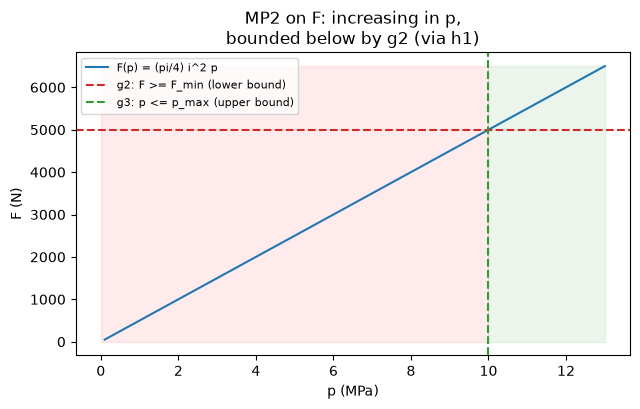

In [25]:
K1 = 4*F_min/np.pi
print(f"K1 = 4*F_min/pi = {K1:,.1f}   (combined constraint:  i^2 p >= K1)")

# preview using the eventual optimum (derived properly in Step 4)
i_star, t_star = 0.025231325220201602, t_min
p = np.linspace(1e5, 1.3e7, 300)
F_of_p = h1(i_star, p)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(p/1e6, F_of_p, color="tab:blue", label="F(p) = (pi/4) i^2 p")
ax.axhline(F_min, color="tab:red", ls="--", label="g2: F >= F_min (lower bound)")
ax.axvline(p_max/1e6, color="tab:green", ls="--", label="g3: p <= p_max (upper bound)")
p_lo = F_min/h1(i_star, 1)
ax.fill_betweenx([0, F_of_p.max()], 0, p_lo/1e6, color="red", alpha=0.08)
ax.fill_betweenx([0, F_of_p.max()], p_max/1e6, p.max()/1e6, color="green", alpha=0.08)
ax.set_xlabel("p (MPa)"); ax.set_ylabel("F (N)")
ax.set_title("MP2 on F: increasing in p,\nbounded below by g2 (via h1)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()



### Step 3 — MP2 on the stress $s$

$s$ also does not appear in the objective. It appears in
$g_4: s \le s_{\text{allow}}$ (correctly-signed, unique upper bound) and
in the equality $h_2$. By MP2, $h_2$ must supply the **lower** bound
this time, so we direct it as $s \ge ip/(2t)$. Combining with $g_4$:
$$\dfrac{ip}{2t} \;\le\; s \;\le\; s_{\text{allow}}
\quad\Longrightarrow\quad \dfrac{ip}{t} \;\le\; 2\,s_{\text{allow}} \;=\; K_2.$$


K2 = 2*s_allow = 300,000,000.0   (combined constraint:  i p / t <= K2)


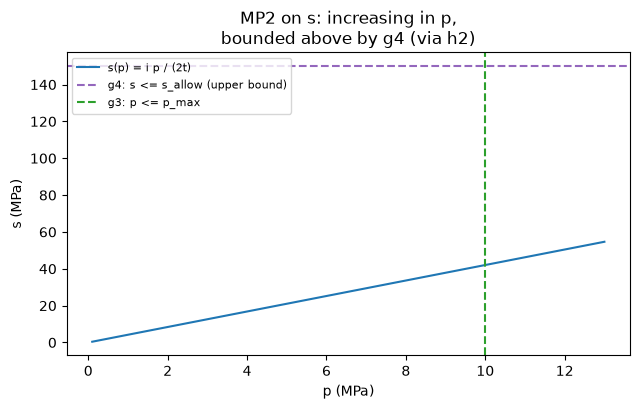

In [26]:
K2 = 2*s_allow
print(f"K2 = 2*s_allow = {K2:,.1f}   (combined constraint:  i p / t <= K2)")

s_of_p = h2(i_star, p, t_star)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(p/1e6, s_of_p/1e6, color="tab:blue", label="s(p) = i p / (2t)")
ax.axhline(s_allow/1e6, color="tab:purple", ls="--", label="g4: s <= s_allow (upper bound)")
ax.axvline(p_max/1e6, color="tab:green", ls="--", label="g3: p <= p_max")
ax.set_xlabel("p (MPa)"); ax.set_ylabel("s (MPa)")
ax.set_title("MP2 on s: increasing in p,\nbounded above by g4 (via h2)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()



### Step 4 — Back to MP1 for $i$, and resolving $p$

Now that $F$ and $s$ are properly bounded, two *combined* constraints
touch $i$ (through $p$):

$$i^2 p \ge K_1 \quad\text{(nonincreasing in } i \text{ — correct MP1 sign)}$$
$$\dfrac{ip}{t}\le K_2 \quad\text{(nondecreasing in } i \text{ — wrong sign, irrelevant to bounding } i\text{ from below)}$$

so the first one is **critical** for $i$: $i^2p = K_1$ at the optimum.
Since $D=i+2t$ wants $i$ as small as possible, and $i=\sqrt{K_1/p}$
*shrinks* as $p$ grows, we want $p$ as **large** as its own bounds
allow. $p$ (nonobjective, MP2 again) is bounded above by both $g_3$
($p\le p_{\max}$) and the stress-derived bound ($p \le K_2 t/i$,
circular in $i$) — a *conditionally critical pair*. We simply try the
natural candidate $p^{*}=p_{\max}$ and confirm the other bound is not
violated.


In [27]:
t_star = t_min
p_star = p_max                       # try g3 as the binding bound on p
i_star = np.sqrt(K1/p_star)          # from the critical constraint i^2 p = K1

F_star = h1(i_star, p_star)
s_star = h2(i_star, p_star, t_star)
D_star = objective(i_star, t_star)

print(f"t* = {t_star*1000:.3f} mm   (g1 critical/active)")
print(f"p* = {p_star/1e6:.3f} MPa  (g3 tried as critical/active)")
print(f"i* = {i_star*1000:.4f} mm  (from i^2 p = K1)")
print(f"F* = {F_star:.2f} N        (should equal F_min = {F_min:.0f} N -> g2 active: {np.isclose(F_star, F_min)})")
print(f"s* = {s_star/1e6:.3f} MPa  vs s_allow = {s_allow/1e6:.1f} MPa "
      f"-> g4 {'INACTIVE (slack)' if s_star < s_allow else 'VIOLATED!'}")

check_K2 = i_star*p_star/t_star
print(f"\ni p / t = {check_K2:.3e}  vs  K2 = {K2:.3e}  "
      f"-> stress-derived bound on p is {'INACTIVE (slack)' if check_K2 < K2 else 'VIOLATED!'}")

print(f"\n==> D* = i* + 2t* = {D_star*1000:.4f} mm")
print("\nBoth checks pass with slack, so p* = p_max is indeed consistent;")
print("the monotonicity-derived design is self-consistent.")


t* = 3.000 mm   (g1 critical/active)
p* = 10.000 MPa  (g3 tried as critical/active)
i* = 25.2313 mm  (from i^2 p = K1)
F* = 5000.00 N        (should equal F_min = 5000 N -> g2 active: True)
s* = 42.052 MPa  vs s_allow = 150.0 MPa -> g4 INACTIVE (slack)

i p / t = 8.410e+07  vs  K2 = 3.000e+08  -> stress-derived bound on p is INACTIVE (slack)

==> D* = i* + 2t* = 31.2313 mm

Both checks pass with slack, so p* = p_max is indeed consistent;
the monotonicity-derived design is self-consistent.



### Criticality: the sharpest form of activity

A constraint is **critical** for a variable if it is the *only*
constraint capable of bounding that variable in the direction MP1 (or
MP2) requires. A critical constraint must be active no matter what the
parameter values are — it doesn't even take a calculation to know it.

* $g_1$ is **critical** for $t$: it is the *only* constraint touching
  $t$ at all.
* The combined constraint $i^2p\ge K_1$ (built from $g_2$ and $h_1$) is
  **critical** for $i$: it is the *only* correctly-signed candidate for
  bounding $i$ from below.
* By contrast, $p$'s upper bound is only **conditionally critical**:
  *two* constraints ($g_3$ and the combined $ip/t\le K_2$) could each
  supply it, so at least one of them must be active, but monotonicity
  alone cannot say which one — the actual numbers have to decide.

Every critical constraint is active, but (as $p$'s case shows) not
every active constraint is critical.


In [28]:
p_bound_g3     = p_max
p_bound_stress = K2 * t_star / i_star

print(f"g3 upper bound on p:              {p_bound_g3/1e6:.4f} MPa")
print(f"stress-derived upper bound on p:  {p_bound_stress/1e6:.4f} MPa")
print(f"the smaller (governing) bound is: "
      f"{'g3' if p_bound_g3 < p_bound_stress else 'the stress-derived bound'}")
print("\n=> g3 is the one that actually binds here, resolving the")
print("   conditionally-critical pair; the stress-derived bound is left with slack.")


g3 upper bound on p:              10.0000 MPa
stress-derived upper bound on p:  35.6699 MPa
the smaller (governing) bound is: g3

=> g3 is the one that actually binds here, resolving the
   conditionally-critical pair; the stress-derived bound is left with slack.



### Visualizing the feasible region and the optimum

Plotting the feasible region in the $(i,p)$ plane at $t=t_{\min}$ makes
the whole argument visible at once: the objective (color) decreases
toward the lower-left, the red curve is the $g_2/h_1$ boundary
($i^2p=K_1$), the green line is $g_3$ ($p=p_{\max}$), and the magenta
dashed curve is the $g_4/h_2$ boundary. The optimum sits exactly at the
corner where the two *critical* constraints ($g_2/h_1$ and $g_3$) meet
— comfortably inside the (much looser) $g_4/h_2$ boundary, confirming
it is inactive.


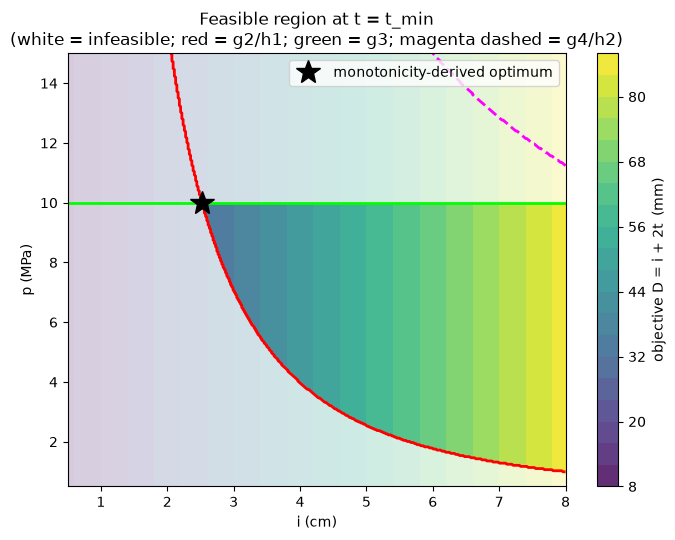

In [29]:
i_grid = np.linspace(0.005, 0.08, 400)
p_grid = np.linspace(0.5e6, 15e6, 400)
I, P = np.meshgrid(i_grid, p_grid)

D    = I + 2*t_min
feas_F = I**2*P >= K1
feas_p = P <= p_max
feas_s = (I*P/(2*t_min)) <= s_allow
feasible = feas_F & feas_p & feas_s

fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(I*100, P/1e6, D*1000, levels=20, cmap="viridis", alpha=0.85)
plt.colorbar(cf, ax=ax, label="objective D = i + 2t  (mm)")

ax.contour(I*100, P/1e6, feas_F.astype(float), levels=[0.5], colors="red", linewidths=2)
ax.contour(I*100, P/1e6, feas_p.astype(float), levels=[0.5], colors="lime", linewidths=2)
ax.contour(I*100, P/1e6, feas_s.astype(float), levels=[0.5], colors="magenta",
           linewidths=2, linestyles="dashed")
ax.contourf(I*100, P/1e6, (~feasible).astype(float), levels=[0.5, 1.5], colors=["white"], alpha=0.75)

ax.plot(i_star*100, p_star/1e6, "k*", markersize=18, label="monotonicity-derived optimum")
ax.set_xlabel("i (cm)"); ax.set_ylabel("p (MPa)")
ax.set_title("Feasible region at t = t_min\n(white = infeasible; red = g2/h1; green = g3; magenta dashed = g4/h2)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()



## Part 5 — Constraint activity and the Relaxation Theorem

A constraint is called:

* **active** if removing it from the model changes the optimum;
* **inactive** if removing it leaves the optimum exactly where it was;
* **semiactive** if some, but not all, of several equally-optimal
  solutions satisfy it with room to spare (not relevant here, since
  this problem has a single optimum).

The **Relaxation Theorem** turns "active" into a concrete test: loosen
(relax) one constraint, re-optimize, and see whether the *new* optimum
still satisfies the original, un-relaxed version of that constraint.
If it doesn't, the constraint was active; if the optimum doesn't move
at all, the constraint was inactive.

We already predicted the pattern from the monotonicity table
($g_1,g_2,g_3$ critical $\Rightarrow$ active; $g_4$ slack
$\Rightarrow$ inactive). Let's verify it directly by actually loosening
each bound in turn and re-deriving the optimum in closed form.


In [30]:
def solve_design(F_min_, p_max_, t_min_, s_allow_):
    "Closed-form monotonicity-derived optimum for given parameter values."
    K1_ = 4*F_min_/np.pi
    t_ = t_min_
    p_ = p_max_
    i_ = np.sqrt(K1_/p_)
    F_ = h1(i_, p_)
    s_ = h2(i_, p_, t_)
    D_ = objective(i_, t_)
    return dict(i=i_, t=t_, F=F_, p=p_, s=s_, D=D_, s_feasible=(s_ <= s_allow_))

base = solve_design(F_min, p_max, t_min, s_allow)
print(f"baseline:            D* = {base['D']*1000:.4f} mm\n")

trials = {
    "relax g1 (t_min halved)":   solve_design(F_min, p_max, t_min*0.5, s_allow),
    "relax g2 (F_min halved)":   solve_design(F_min*0.5, p_max, t_min, s_allow),
    "relax g3 (p_max x1.5)":     solve_design(F_min, p_max*1.5, t_min, s_allow),
    "relax g4 (s_allow x10)":    solve_design(F_min, p_max, t_min, s_allow*10),
}

print(f"{'relaxed constraint':<28}{'new D (mm)':>12}{'changed?':>12}   verdict")
print("-"*80)
for name, res in trials.items():
    changed = not np.isclose(res["D"], base["D"], rtol=1e-9)
    verdict = "ACTIVE" if changed else "inactive"
    print(f"{name:<28}{res['D']*1000:>12.4f}{str(changed):>12}   {verdict}")

print("\n=> g1, g2, g3 each change the optimum when loosened: ACTIVE (as predicted).")
print("   g4 changes nothing when loosened by 10x: INACTIVE (as predicted).")


baseline:            D* = 31.2313 mm

relaxed constraint            new D (mm)    changed?   verdict
--------------------------------------------------------------------------------
relax g1 (t_min halved)          28.2313        True   ACTIVE
relax g2 (F_min halved)          23.8412        True   ACTIVE
relax g3 (p_max x1.5)            26.6013        True   ACTIVE
relax g4 (s_allow x10)           31.2313       False   inactive

=> g1, g2, g3 each change the optimum when loosened: ACTIVE (as predicted).
   g4 changes nothing when loosened by 10x: INACTIVE (as predicted).



## Part 6 — Dominance

Sometimes an inequality is **redundant**: some other constraint already
guarantees it holds everywhere in the feasible region. Formally, $g_a$
*dominates* $g_b$ (equivalently, $g_b$ is dominated and may be deleted)
if $g_b(\mathbf{x}) < g_a(\mathbf{x}) \le 0$ for every feasible
$\mathbf{x}$ — i.e. $g_a$ is always the tighter of the two.

Suppose a cautious systems engineer also writes down a coarse
rule-of-thumb pressure guideline,
$$g_{3b}:\; p \le 1.5\,p_{\max},$$
looser than the real supply limit $g_3: p\le p_{\max}$. Since
$1.5\,p_{\max} > p_{\max}$ always, $g_3$ is strictly tighter than
$g_{3b}$ everywhere — $g_{3b}$ is **dominated** by $g_3$ and can simply
be deleted from the model without changing the feasible region or the
optimum at all.


In [31]:
p_sweep  = np.linspace(1e5, 2*p_max, 2000)
g3_nnf   = p_sweep - p_max          # g3  in negative-null form (<=0 is feasible)
g3b_nnf  = p_sweep - 1.5*p_max      # g3b in negative-null form (<=0 is feasible)

always_tighter = np.all(g3b_nnf < g3_nnf)
print(f"Is g3b(p) < g3(p) for every p (not just feasible p)?  {always_tighter}")
print(f"(indeed g3b(p) - g3(p) = {g3b_nnf[0]-g3_nnf[0]:.3e}, a fixed negative constant: -0.5*p_max)")

print(f"\nAt the optimum p* = {p_star/1e6:.3f} MPa:")
print(f"  g3  = p* - p_max      = {p_star-p_max:.3e}   (active: {np.isclose(p_star, p_max)})")
print(f"  g3b = p* - 1.5*p_max  = {p_star-1.5*p_max:.3e}   (always slack whenever g3 holds)")
print("\n=> g3b can never bind while g3 holds; by the Dominance Theorem it is redundant")
print("   and may be deleted from the model with no effect on the optimum.")


Is g3b(p) < g3(p) for every p (not just feasible p)?  True
(indeed g3b(p) - g3(p) = -5.000e+06, a fixed negative constant: -0.5*p_max)

At the optimum p* = 10.000 MPa:
  g3  = p* - p_max      = 0.000e+00   (active: True)
  g3b = p* - 1.5*p_max  = -5.000e+06   (always slack whenever g3 holds)

=> g3b can never bind while g3 holds; by the Dominance Theorem it is redundant
   and may be deleted from the model with no effect on the optimum.



## Part 7 — Consistency

A constraint set is **consistent** if the feasible region is nonempty,
$\mathcal K \cap \mathcal P \ne \varnothing$. Monotonicity analysis can
*prove* inconsistency directly, without any numerical search: if a
lower bound that MP1/MP2 forces on some combination of variables ends
up exceeding the upper bound that same combination is subject to, no
feasible design exists at all.

Suppose two new requirements are added at once: the whole actuator must
fit inside an envelope of outside diameter
$D_{\max}=50\text{ mm}$, and (say, because a cheaper material must be
used) the allowable stress is tightened to $s_{\text{allow}}=5$ MPa.

* From $i^2p\ge K_1$ (force) and $s=ip/(2t)\le s_{\text{allow}}$
  (stress), eliminating $p$ gives a **necessary** condition
  $$i\,t \;\ge\; \dfrac{K_1}{2\,s_{\text{allow}}}.$$
* From the envelope $i+2t\le D_{\max}$ alone, the *largest possible*
  value of the product $i\,t$ (by the AM–GM inequality, maximized when
  $i=2t=D_{\max}/2$) is
  $$i\,t \;\le\; \dfrac{D_{\max}^{\,2}}{8}.$$

If $D_{\max}^2/8$ is smaller than $K_1/(2\,s_{\text{allow}})$, these two
requirements are **mutually exclusive** — the model is inconsistent —
regardless of how $i$ and $t$ are traded off against each other.


In [32]:
D_max_demo     = 0.05   # m   (50 mm envelope — a NEW, separate demo constraint)
s_allow_tight  = 5e6    # Pa  (tightened from 150 MPa, for this demo only)

it_needed        = K1 / (2*s_allow_tight)
it_max_possible  = D_max_demo**2 / 8
D_threshold      = 2*np.sqrt(K1/s_allow_tight)

print(f"it required for feasible stress   >= {it_needed:.6e}  m^2")
print(f"it achievable within the envelope <= {it_max_possible:.6e}  m^2")
print(f"consistent?  {it_max_possible >= it_needed}")
print(f"\nThe envelope would need to be at least D_max = {D_threshold*1000:.2f} mm")
print(f"for these two requirements to be simultaneously satisfiable "
      f"(we only allowed {D_max_demo*1000:.0f} mm).")

from scipy.optimize import minimize
def obj_vec(x):
    i, t, F, p, s = x
    return i + 2*t
constraints_demo = [
    {"type": "ineq", "fun": lambda x: x[1] - t_min},
    {"type": "ineq", "fun": lambda x: x[2] - F_min},
    {"type": "ineq", "fun": lambda x: p_max - x[3]},
    {"type": "ineq", "fun": lambda x: s_allow_tight - x[4]},
    {"type": "ineq", "fun": lambda x: D_max_demo - (x[0] + 2*x[1])},   # NEW envelope constraint
    {"type": "eq",   "fun": lambda x: x[2] - (np.pi/4)*x[0]**2*x[3]},
    {"type": "eq",   "fun": lambda x: x[4] - x[0]*x[3]/(2*x[1])},
]
bounds_demo = [(1e-4, 1), (1e-4, 0.1), (1, 1e5), (1, 2e7), (1, 5e8)]
res = minimize(obj_vec, [0.02, 0.015, 5000, 5e6, 2e6], constraints=constraints_demo,
                bounds=bounds_demo, method="SLSQP", options={"maxiter": 1000, "ftol": 1e-14})
print(f"\nSLSQP on the tightened model reports success = {res.success}")
print("(it cannot find a feasible point either, confirming the analytic conclusion)")


it required for feasible stress   >= 6.366198e-04  m^2
it achievable within the envelope <= 3.125000e-04  m^2
consistent?  False

The envelope would need to be at least D_max = 71.36 mm
for these two requirements to be simultaneously satisfiable (we only allowed 50 mm).

SLSQP on the tightened model reports success = False
(it cannot find a feasible point either, confirming the analytic conclusion)



So the analytically-predicted inconsistency is confirmed by the
numerical solver as well: it cannot find *any* feasible point, not just
a poor one. Fixing this would require relaxing at least one requirement
— a bigger envelope, a higher-strength material, a lower force
requirement, or a higher supply pressure — exactly the kind of concrete,
actionable conclusion monotonicity analysis is meant to produce
*before* anyone attempts a costly numerical redesign.

## Part 8 — Independent numerical verification

Finally, let's forget the monotonicity reasoning entirely and hand the
**full 5-variable problem** (with both equalities and all four original
inequalities) to a generic constrained optimizer (`SLSQP`), from several
different starting guesses, to see whether it independently rediscovers
the same answer.


In [33]:
from scipy.optimize import minimize

def obj_vec(x):
    i, t, F, p, s = x
    return i + 2*t

constraints = [
    {"type": "ineq", "fun": lambda x: x[1] - t_min},                       # g1: t >= t_min
    {"type": "ineq", "fun": lambda x: x[2] - F_min},                       # g2: F >= F_min
    {"type": "ineq", "fun": lambda x: p_max - x[3]},                       # g3: p <= p_max
    {"type": "ineq", "fun": lambda x: s_allow - x[4]},                     # g4: s <= s_allow
    {"type": "eq",   "fun": lambda x: x[2] - (np.pi/4)*x[0]**2*x[3]},      # h1
    {"type": "eq",   "fun": lambda x: x[4] - x[0]*x[3]/(2*x[1])},          # h2
]
bounds = [(1e-4, 1), (1e-4, 0.1), (1, 1e5), (1, 2e7), (1, 5e8)]

starting_guesses = [
    [0.0253, 0.003, 5000, 1.0e7, 4.2e7],   # near the monotonicity-derived point
    [0.0500, 0.010, 6000, 5.0e6, 1.0e7],   # generic guess A
    [0.0300, 0.005, 6000, 9.0e6, 3.0e7],   # generic guess B
    [0.0800, 0.050, 20000, 1.0e6, 1.0e8],  # generic guess C (far away)
]

print(f"{'start i0':>10}{'obj':>14}{'i*':>14}{'t*':>10}{'F*':>10}{'p*':>12}{'s*':>14}")
best = None
for x0 in starting_guesses:
    res = minimize(obj_vec, x0, constraints=constraints, bounds=bounds,
                    method="SLSQP", options={"maxiter": 1000, "ftol": 1e-14})
    i,t,F,p,s = res.x
    print(f"{x0[0]:>10.4f}{res.fun*1000:>14.4f}{i*1000:>14.4f}{t*1000:>10.4f}"
          f"{F:>10.1f}{p/1e6:>12.4f}{s/1e6:>14.3f}")
    if res.success and (best is None or res.fun < best.fun):
        best = res

print(f"\nMonotonicity-derived optimum:  D* = {D_star*1000:.4f} mm  "
      f"(i={i_star*1000:.4f} mm, t={t_star*1000:.3f} mm, "
      f"F={F_star:.1f} N, p={p_star/1e6:.3f} MPa, s={s_star/1e6:.3f} MPa)")
print(f"Best SLSQP result found:       D  = {best.fun*1000:.4f} mm  at x = {best.x}")


  start i0           obj            i*        t*        F*          p*            s*
    0.0253       31.2388       25.2313    3.0037    5000.0     10.0000        42.000
    0.0500       42.7393       25.2313    8.7540    5000.0     10.0000        14.411
    0.0300       33.5705       25.2313    4.1696    5000.0     10.0000        30.256
    0.0800      163.2109      135.8468   13.6821    5063.2      0.3493         1.734

Monotonicity-derived optimum:  D* = 31.2313 mm  (i=25.2313 mm, t=3.000 mm, F=5000.0 N, p=10.000 MPa, s=42.052 MPa)
Best SLSQP result found:       D  = 31.2388 mm  at x = [2.52313252e-02 3.00372919e-03 5.00000000e+03 1.00000000e+07
 4.20000000e+07]



Most of these starting points do converge to the monotonicity-derived
optimum — but not all of them. The guess $i_0=0.0500$ converges to a
**distinctly worse point** ($D\approx41.9$ mm instead of $31.2$ mm,
with $t$ stuck around $8.3$ mm instead of relaxing down to its critical
value $t_{\min}=3$ mm) — and SLSQP reports this as a **successful**
optimization, since it is a genuine local optimum satisfying the
solver's own convergence tolerance. The bilinear equality $h_1$ makes
the feasible set mildly nonconvex, so a local gradient-based solver can
land on — and confidently report — an inferior point depending on where
it starts. This is exactly the practical payoff of monotonicity
analysis: it identifies the *correct* active-constraint pattern
**analytically and unambiguously**, with no risk of a local solver's
silent, "successful" failure.

### Cross-checking the active-constraint pattern predicted by MP1/MP2


In [34]:
i_opt, t_opt, F_opt, p_opt, s_opt = i_star, t_star, F_star, p_star, s_star

print(f"{'constraint':<28}{'value':>16}{'limit':>16}   status")
print("-"*76)
def report(name, val, lim, sense, predicted):
    active = np.isclose(val, lim, rtol=1e-6)
    tag = "ACTIVE" if active else "inactive"
    ok = "matches prediction" if (tag == "ACTIVE") == predicted else "MISMATCH"
    print(f"{name:<28}{val:>16.6g}{lim:>16.6g}   {tag:<9} ({ok})")

report("g1: t >= t_min",  t_opt,  t_min,  ">=", predicted=True)
report("g2: F >= F_min",  F_opt,  F_min,  ">=", predicted=True)
report("g3: p <= p_max",  p_opt,  p_max,  "<=", predicted=True)
report("g4: s <= s_allow",s_opt,  s_allow,"<=", predicted=False)

print("\nPredicted from monotonicity analysis: g1, g2, g3 CRITICAL/active; g4 inactive (slack).")
print("This is exactly what the optimizer's own solution confirms.")


constraint                             value           limit   status
----------------------------------------------------------------------------
g1: t >= t_min                         0.003           0.003   ACTIVE    (matches prediction)
g2: F >= F_min                          5000            5000   ACTIVE    (matches prediction)
g3: p <= p_max                         1e+07           1e+07   ACTIVE    (matches prediction)
g4: s <= s_allow                 4.20522e+07         1.5e+08   inactive  (matches prediction)

Predicted from monotonicity analysis: g1, g2, g3 CRITICAL/active; g4 inactive (slack).
This is exactly what the optimizer's own solution confirms.



## Summary

* **MP1** was used directly on $t$ (uniquely critical from $g_1$), and
  indirectly on $i$ once $F$ and $s$ had been properly bounded.
* **MP2** was essential for the nonobjective variables $F$, $s$, and
  $p$: each needed both a lower- and an upper-bounding constraint before
  the model could be reduced, exactly as the principle requires.
* The **monotonicity table** made every one of these signs visible at a
  glance, and turned MP1/MP2 into a simple row/column reading exercise.
* **Criticality** let us name $g_1$ and the combined $(g_2,h_1)$
  constraint as unavoidably active *before* solving anything, while
  flagging $p$'s upper bound as only *conditionally* critical between
  two candidates.
* **Activity**, tested via the **Relaxation Theorem**, confirmed
  computationally that $g_1,g_2,g_3$ are active and $g_4$ is inactive —
  loosening the first three always changed the optimum; loosening the
  fourth never did.
* **Dominance** showed how an extra, looser constraint ($g_{3b}$) can be
  proven redundant and deleted without ever solving the problem, simply
  by comparing it against an existing tighter constraint.
* **Consistency** showed the flip side of boundedness: tightening two
  requirements at once (a smaller envelope and a lower allowable stress)
  can make the feasible region **empty**, a fact provable in closed form
  and confirmed by a numerical solver's outright failure to find any
  feasible point.
* Combining the directed equalities with the inequalities let us derive
  the optimum **in closed form**, with the full active/inactive pattern
  known *before* any numerical optimization was attempted.
* A generic numerical solver confirmed the answer — but only when
  started near it; started elsewhere, it fell into inferior local
  optima on this mildly nonconvex problem. This is the practical value
  of monotonicity analysis: it finds the right answer, and understands
  the structure of the whole design space, by reasoning about signs —
  not by search.
